<a href="https://colab.research.google.com/github/komorimasashi/HIS2024-GenAI/blob/main/Furusato_Tax_Return_Goods_Analysis_gemini.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ふるさと納税返礼品の説明の分析

「茨木市ふるさと納税返礼品「鶏のすき焼き缶」の開発：産学官連携プロジェクト」で集められたデータ．
長岡千賀先生（追手門学院大学）から提供を受けた

長岡千賀. (2020). 製品パッケージと説明コピーの作成に向けた心理学的検討: 茨木市ふるさと納税返礼品 「鶏のすき焼き缶」 の開発. 追手門経営論集; Otemon business management review, 25(2), 51-62.

商品カテゴリ（缶詰，弁当，本製品（鶏のすき焼き缶）），商品名，およびこれらの説明の記述のデータ．


「さとふる缶詰と弁当と本製品説明書き.txt」をドラッグアンドドロップしてから実行してください．

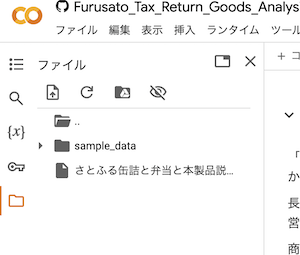

## 分析準備

In [1]:
!pip install openai
!apt-get -y install fonts-ipafont-gothic
!pip install japanize-matplotlib

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following additional packages will be installed:
  fonts-ipafont-mincho
The following NEW packages will be installed:
  fonts-ipafont-gothic fonts-ipafont-mincho
0 upgraded, 2 newly installed, 0 to remove and 41 not upgraded.
Need to get 8,237 kB of archives.
After this operation, 28.7 MB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/universe amd64 fonts-ipafont-gothic all 00303-21ubuntu1 [3,513 kB]
Get:2 http://archive.ubuntu.com/ubuntu jammy/universe amd64 fonts-ipafont-mincho all 00303-21ubuntu1 [4,724 kB]
Fetched 8,237 kB in 2s (4,370 kB/s)
Selecting previously unselected package fonts-ipafont-gothic.
(Reading database ... 121713 files and directories currently installed.)
Preparing to unpack .../fonts-ipafont-gothic_00303-21ubuntu1_all.deb ...
Unpacking fonts-ipafont-gothic (00303-21ubuntu1) ...
Selecting previously unselected package fonts-ipa

In [2]:
import pandas as pd
import numpy as np
from sklearn.manifold import TSNE
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage
import matplotlib.pyplot as plt
import re
import pandas as pd
from bs4 import BeautifulSoup
from google.colab import userdata
import seaborn as sns
import matplotlib.pyplot as plt
import japanize_matplotlib
import time


## テキストデータの前処理

In [3]:
def clean_text(text):
    # 特殊文字や句読点を削除
    # text = re.sub(r"[^\w\s]", " ", text)
    # 単一文字を削除
    # text = re.sub(r"\b[a-zA-Z]\b", " ", text)
    # HTMLタグを削除
    text = re.sub(r"<[^>]*>", " ", text)
    # テキストを小文字化
    # text = text.lower()
    # 余分な空白を削除
    text = re.sub(r"\s+", " ", text)
    # 先頭と末尾の空白を削除
    text = text.strip()
    # 全角スペースを削除
    #text = re.sub(r'\u3000', '', text)
    # 特定のパターンを置換
    #text = re.sub(r"^\('(.+?)',\)$", r'\1', text)
    return text

In [4]:
# ファイルを読み込む
with open('さとふる缶詰と弁当と本製品説明書き.txt', 'r', encoding='shift_jis') as file:
    content = file.read()

# BeautifulSoupを使ってHTMLを解析
soup = BeautifulSoup(content, 'html.parser')

# データを格納するリストを初期化
data = []

# <H1>と<H2>タグを順に処理
for h1_tag in soup.find_all('h1'):
    category = h1_tag.text.strip()
    h2_tags = h1_tag.find_next_siblings('h2')
    for h2_tag in h2_tags:
        # <H2>タグが次の<H1>までの間にあるかを確認
        if h2_tag.find_previous_sibling('h1') == h1_tag:
            product_name = h2_tag.text.strip()
            description = h2_tag.find_next_sibling(text=True).strip()
            data.append([category, product_name, clean_text(description)])

# データフレームに変換
df = pd.DataFrame(data, columns=['Category', 'Product Name', 'Description'])

# 結果を表示
df

FileNotFoundError: [Errno 2] No such file or directory: 'さとふる缶詰と弁当と本製品説明書き.txt'

## Geminiによる埋込み

In [ ]:
import os
import pandas as pd
from bs4 import BeautifulSoup
import google.generativeai as genai
from sklearn.decomposition import PCA
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
GEMINI_API_KEY=userdata.get('GOOGLE_API_KEY')

In [ ]:
genai.configure(api_key=GEMINI_API_KEY)

### text-embedding-004モデルによる埋込み

Gemini の生成モデルを使ってテキストを英語に翻訳する関数

In [ ]:
def translate_to_english(text):
    model = genai.GenerativeModel("gemini-1.5-pro")
    prompt = f"Translate the following text into English:\n\n{text}"

    try:
        response = model.generate_content(prompt)
        time.sleep(10)  # APIの連続呼び出し対策
        return response.text.strip()
    except Exception as e:
        print(f"Translation error for text: {text}\n{e}")
        return None

text-embedding-004（非多言語モデル） を使ってテキストの埋め込みを取得する関数

In [ ]:
def get_embedding(text):
    try:
        result = genai.embed_content(
            model="models/text-embedding-004",
            content=text
        )
        # API連続呼び出し対策として10秒待機
        time.sleep(10)
        return result['embedding']
    except Exception as e:
        print(f"Error for text: {text}\n{e}")
        return None

テキストをまず英語に翻訳し、翻訳結果を使って埋め込みを取得する関数

In [ ]:
def get_embedding_with_translation(text):
    english_text = translate_to_english(text)
    if english_text is None:
        return None
    print(f"Translated text: {english_text}")
    embedding = get_embedding(english_text)
    return embedding

In [ ]:
# Embedding を作成
embeddings = []
successful_indices = []

for i, description in enumerate(df['Description']):
    try:
        # print(i, description)
        embedding = get_embedding_with_translation(description)
        embeddings.append(embedding)
        successful_indices.append(i)
        time.sleep(1)
    except Exception as e:
        print(f"Embedding failed for index {i}: {e}")

# 成功した行だけをデータフレームに残す
df = df.iloc[successful_indices].reset_index(drop=True)
df["embedding"] = embeddings
embeddings_array_gemini = np.array(df["embedding"].tolist())

768次元のベクトルとして表現される

### 可視化

In [ ]:
# フォントの設定
plt.rcParams['font.family'] = 'IPAPGothic'
japanize_matplotlib.japanize()

#### 主成分分析

In [ ]:
pca = PCA(n_components=2)
reduced = pca.fit_transform(embeddings_array_gemini)

df["PCA1"] = reduced[:, 0]
df["PCA2"] = reduced[:, 1]

plt.figure(figsize=(10, 8))
plt.scatter(df["PCA1"], df["PCA2"], alpha=0.7)
for i, row in df.iterrows():
    plt.annotate(row["Product Name"], (row["PCA1"], row["PCA2"]), fontsize=8)
plt.title("Gemini API Embedding PCA 可視化")
plt.xlabel("主成分 1")
plt.ylabel("主成分 2")
plt.grid(True)
plt.show()

In [ ]:
# Ward法による階層型クラスタリング
linkage_matrix = linkage(embeddings_array_gemini, method='ward')
clusters = AgglomerativeClustering(n_clusters=5, metric='euclidean', linkage='ward').fit_predict(embeddings_array_gemini)

# クラスタリング結果をデータフレームに追加
df['Cluster'] = clusters

# デンドログラムをプロット
plt.figure(figsize=(12, 8))
dendrogram(linkage_matrix, labels=df['Product Name'].values, leaf_rotation=90)
plt.title('Dendrogram (Hierarchical Clustering using Ward method)')
plt.xlabel('Product Name')
plt.ylabel('Distance')
plt.show()


## ChatGPTによる埋込み

In [ ]:
OPENAI_API_KEY=userdata.get('OPENAI_API_KEY')

In [ ]:
from openai import OpenAI

client = openai.OpenAI(api_key=OPENAI_API_KEY)


def get_embedding(text, model="text-embedding-3-small", dim=None):
    text = text.replace("\n", " ")
    if dim is None:
        return client.embeddings.create(input=[text], model=model).data[0].embedding
    else:
        return (
            client.embeddings.create(input=[text], model=model, dimensions=dim)
            .data[0]
            .embedding
        )

In [ ]:
# Embeddingを作成
embeddings = []
successful_indices = []

for i, description in enumerate(df['Description']):
  try:
    embedding = get_embedding(
        text=description,
        model="text-embedding-3-small"
    )
    embeddings.append(embedding)
    successful_indices.append(i)
  except Exception as e:
    print(f"Embedding failed for index {i}")

# 成功した行だけをデータフレームに残す
df = df.iloc[successful_indices].reset_index(drop=True)

1536次元のベクトルとして表現される

In [ ]:
embeddings_array = np.array(embeddings)
embeddings_array.shape

### 可視化

In [ ]:
# フォントの設定
plt.rcParams['font.family'] = 'IPAPGothic'
japanize_matplotlib.japanize()

### クラスタ分析

In [ ]:
# Ward法による階層型クラスタリング
linkage_matrix = linkage(embeddings_array, method='ward')
clusters = AgglomerativeClustering(n_clusters=5, metric='euclidean', linkage='ward').fit_predict(embeddings_array)

# クラスタリング結果をデータフレームに追加
df['Cluster'] = clusters

# デンドログラムをプロット
plt.figure(figsize=(12, 8))
dendrogram(linkage_matrix, labels=df['Product Name'].values, leaf_rotation=90)
plt.title('Dendrogram (Hierarchical Clustering using Ward method)')
plt.xlabel('Product Name')
plt.ylabel('Distance')
plt.show()


### t-SNEによる散布図のプロット

In [ ]:
# t-SNEで次元削減
embeddings_array = np.array(embeddings)
tsne = TSNE(n_components=2)
tsne_results = tsne.fit_transform(embeddings_array)

# データフレームにt-SNEの結果を追加
df['tsne-2d-one'] = tsne_results[:, 0]
df['tsne-2d-two'] = tsne_results[:, 1]


In [ ]:
# 色をカテゴリごとに設定
unique_categories = df['Category'].unique()
palette = sns.color_palette("hsv", len(unique_categories))
category_color_mapping = {category: palette[i] for i, category in enumerate(unique_categories)}

# 散布図をプロット
plt.figure(figsize=(10, 8))
sns.scatterplot(
    x="tsne-2d-one", y="tsne-2d-two",
    hue="Category",
    palette=category_color_mapping,
    data=df,
    legend="full",
    alpha=0.8
)

# 各ポイントに商品名を表示
for i, product_name in enumerate(df['Product Name']):
    plt.text(tsne_results[i, 0], tsne_results[i, 1], product_name, fontsize=8)

plt.title('t-SNE visualization of product descriptions by category')
plt.xlabel('t-SNE dimension 1')
plt.ylabel('t-SNE dimension 2')
plt.grid(True)
plt.show()

## BERT（おまけ）

日本語pre-trained model（東北大学）を使用

In [ ]:
!pip install transformers
!pip install torch
!pip install fugashi
!pip install ipadic

In [ ]:
import pandas as pd
from transformers import BertModel, BertJapaneseTokenizer
import torch
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import numpy as np
import japanize_matplotlib

In [ ]:
#モデルとトークナイザの設定
model_name = "cl-tohoku/bert-base-japanese-whole-word-masking"#単語

tokenizer = BertJapaneseTokenizer.from_pretrained(model_name)
model = BertModel.from_pretrained(model_name)

In [ ]:
# Embeddingを作成
embeddings = []
successful_indices = []

for i, description in enumerate(df['Description']):
  try:
    inputs = tokenizer(description, return_tensors="pt", max_length=512, truncation=True, padding="max_length")
    with torch.no_grad():
        outputs = model(**inputs)#モデルにトークナイズしたテキストを入力
    cls_embedding = outputs.last_hidden_state[:, 0, :].numpy()#
    embeddings.append(cls_embedding[0])#リストに追加
    successful_indices.append(i)
  except Exception as e:
    print(f"Embedding failed for index {i}")

# 成功した行だけをデータフレームに残す
df = df.iloc[successful_indices].reset_index(drop=True)

In [ ]:
embeddings_array = np.array(embeddings)
embeddings_array.shape

In [ ]:
# Ward法による階層型クラスタリング
linkage_matrix = linkage(embeddings_array, method='ward')
clusters = AgglomerativeClustering(n_clusters=5, metric='euclidean', linkage='ward').fit_predict(embeddings_array)

# クラスタリング結果をデータフレームに追加
df['Cluster'] = clusters

# デンドログラムをプロット
plt.figure(figsize=(12, 8))
dendrogram(linkage_matrix, labels=df['Product Name'].values, leaf_rotation=90)
plt.title('Dendrogram (Hierarchical Clustering using Ward method)')
plt.xlabel('Product Name')
plt.ylabel('Distance')
plt.show()